# Pandas數據分析

今天介紹資料分析近來很紅的 pandas 套件, 作者是 Wes McKinney。Python 會成為一個數據分析的熱門語言, 和 pandas 的出現也有相當的關係。

但是 pandas 雖然功能強, 但有些地方沒那麼直覺, 有時會讓大家以為是個深奧的套件。其實你大約可以把 pandas 想成「Python 的 Excel」, 但是功能更強、更有彈性、也有更多的可能性。

下面介紹個基本上就是把 pandas 當 Excel 學的影片, 相信大家會覺得很親切。<br>
https://youtu.be/9d5-Ti6onew

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1 開始使用 `pandas`

首先我們來讀入一個 CSV 檔, 這裡有個「假的」學測成績, 叫 `grades.csv` 我們來練習一下。

In [3]:
df = pd.read_csv("data/grades.csv")

用 `df` 是標準的叫法 (雖然這名稱我們隨便取也可以), 意思是 Data Frame, 這是 `pandas` 兩大資料結構之一。我們可以把 Data Frame 想成一張表格 (雖然其實可以是很多張表格)。

我們來看看我們 `df` 的前五筆資料。

In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
df.head()

,姓名,國文,英文,數學,自然,社會
0,劉俊安,9,10,15,10,13
1,胡玉華,10,10,10,8,9
2,黃淑婷,13,15,8,11,14
3,陳上紫,10,10,8,9,14
4,崔靜成,13,12,14,12,13


如果你曾經手動讀入 CSV 檔, 就知道這省了多少事 (雖然我個人還挺喜歡純手動帶進 CSV)。

#### Excel 檔也可以快速讀入

不只 CSV 檔, 很多資料檔案, 像 Excel 檔都很容易在 `pandas` 完成。使用法是這樣:

    df2 = pd.read_excel('filename.xls', 'sheetname')
    
其中 sheetname 那裡要放工作表的名稱, 如果是中文的最好改成英文。

## 2 Pandas 基本資料結構

Pandas 有兩個基本資料結構:

* <b style="color:red;">DataFrame</b>: 可以想成一個表格。
* <b style="color:red;">Series</b>: 表格的某一列、某一行, 基本上就是我們以前的 list 或 array

一個 DataFrame, 我們有 `index` (列的名稱), `columns` (行的名稱)。

#### DataFrame

![DataFrame 的結構](images/indexcol.png)

#### Series

剛剛說 series 大概就是一個 list, 一個 array。其實更精準的說, 其實是一個有 "index" 的 array。

DataFrame 的每一行或每一列其實也都是一個 series。我們來看個例子, 例如所有同學的國文成績, 就是一個 series。

In [6]:
df['國文']

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

在 Python 3 中, 我們終於可以和英文同步, 用這種很炫的方式叫出所有國文成績。

In [7]:
df.國文

0      9
1     10
2     13
3     10
4     13
      ..
95     9
96     8
97    14
98    15
99     9
Name: 國文, Length: 100, dtype: int64

#### 資料畫出來

要畫個圖很容易。

<Axes: >

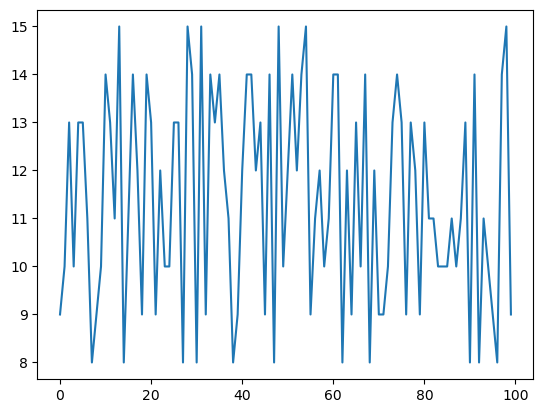

In [8]:
df.國文.plot()

當然, 在這個例子中, 其實畫 histogram 圖更有意義一點。

<Axes: >

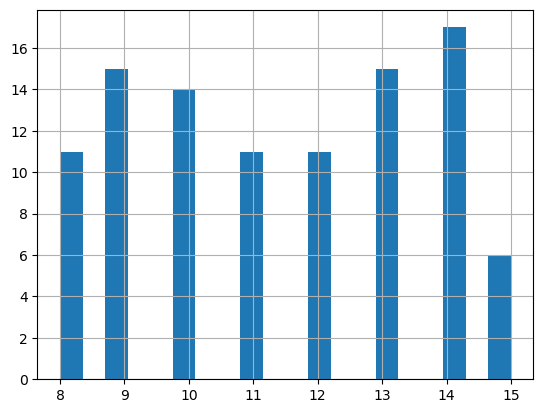

In [14]:
df.國文.hist(bins=20) #hist()繪製直方圖，bins=20將資料分成15各區間

## 3 一些基本的資料分析

算平均。

In [15]:
df.國文.mean() #答案出現np.float64

np.float64(11.39)

In [17]:
float(df.國文.mean()) #答案純數字

11.39

算標準差。

In [19]:
float(df.國文.std()) #float寫最前面

2.1968526614594834

不如就該算的都幫我們算算...

In [21]:
df.describe() #8種統計量算法

,國文,英文,數學,自然,社會
count,100.000000,100.000000,100.000000,100.00000,100.00000
mean,11.390000,11.380000,11.570000,11.03000,11.83000
std,2.196853,2.273164,2.310516,2.21772,2.48655
min,8.000000,8.000000,8.000000,8.00000,8.00000
25%,9.000000,9.000000,10.000000,9.00000,9.00000
50%,11.000000,11.000000,11.000000,11.00000,12.00000
75%,13.000000,13.000000,14.000000,13.00000,14.00000
max,15.000000,15.000000,15.000000,15.00000,15.00000


有時我們很愛看的相關係數矩陣。

In [25]:
df.corr(numeric_only=True) #corr()只能計算數字欄位的相關係數

,國文,英文,數學,自然,社會
國文,1.000000,0.160158,-0.310899,-0.110236,-0.028421
英文,0.160158,1.000000,0.025656,0.113929,-0.063512
數學,-0.310899,0.025656,1.000000,0.014371,0.041651
自然,-0.110236,0.113929,0.014371,1.000000,-0.156594
社會,-0.028421,-0.063512,0.041651,-0.156594,1.000000


In [26]:
df[['國文','英文','數學']].corr() #corr()全名是correlation()

,國文,英文,數學
國文,1.000000,0.160158,-0.310899
英文,0.160158,1.000000,0.025656
數學,-0.310899,0.025656,1.000000


只算兩科間的相關係數當然也可以。

In [28]:
float(df.國文.corr(df.數學)) #使用float()

-0.310898982217933

In [29]:
df[['國文','數學']].corr()

,國文,數學
國文,1.000000,-0.310899
數學,-0.310899,1.000000


## 4 增加一行

### 【技巧】

我們增加一行, 加入總級分。

In [30]:
df["總級分"] = df.sum(axis = 1) #產生錯誤，因為正嘗試把「文字(str)」和「數字(int)」直接相加
df.head()

TypeError: can only concatenate str (not "int") to str

In [31]:
df["總級分"] = df.sum(axis = 1, numeric_only=True)
df.head()

,姓名,國文,英文,數學,自然,社會,總級分
0,劉俊安,9,10,15,10,13,57
1,胡玉華,10,10,10,8,9,47
2,黃淑婷,13,15,8,11,14,61
3,陳上紫,10,10,8,9,14,51
4,崔靜成,13,12,14,12,13,64


### 【技巧】

有計算的當然也可以的。

In [22]:
df["加權"] = df.國文+df.英文+df.數學*2

In [33]:
df #等同於print(df)

,姓名,國文,英文,數學,自然,社會,總級分,加權
0,劉俊安,9,10,15,10,13,57,49
1,胡玉華,10,10,10,8,9,47,40
2,黃淑婷,13,15,8,11,14,61,44
3,陳上紫,10,10,8,9,14,51,36
4,崔靜成,13,12,14,12,13,64,53
...,...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,55,37
96,吳筱婷,8,10,14,10,15,57,46
97,陳家銘,14,9,11,8,12,54,45
98,李明威,15,9,8,9,15,56,40


## 5 排序和 index 重設

### 【重點】排序的方法

我們依總級分來排序。

In [42]:
df.sort_values(by="總級分",ascending=False).head(10) 
# sort_values(by= )進行排序
# ascending是否升冪排序？ =True=>由小到大，=False=>由大到小

,姓名,國文,英文,數學,自然,社會,總級分,加權
81,施雅鈴,13,15,12,13,13,66,52
13,李正偉,11,15,11,14,15,66,48
55,陳怡潔,15,15,9,15,11,65,48
26,蔡亦瑄,13,13,14,13,12,65,54
58,胡淳茜,12,15,14,13,11,65,55
38,曾怡君,11,12,15,13,14,65,53
49,陳怡婷,15,14,12,9,15,65,53
65,俞志峰,9,14,13,14,15,65,49
84,李士賢,10,14,15,13,13,65,54
88,趙偉希,10,13,14,13,15,65,51


### 【重點】排序的方法

加權分最高, 同分才看總級分

In [43]:
df.sort_values(by = ["加權","總級分"],ascending=False).head(10)

,姓名,國文,英文,數學,自然,社會,總級分,加權
74,吳志遠,13,15,15,8,8,59,58
58,胡淳茜,12,15,14,13,11,65,55
37,詹威德,12,13,15,10,14,64,55
26,蔡亦瑄,13,13,14,13,12,65,54
84,李士賢,10,14,15,13,13,65,54
45,童心怡,13,13,14,8,13,61,54
38,曾怡君,11,12,15,13,14,65,53
49,陳怡婷,15,14,12,9,15,65,53
5,崔靜成,13,12,14,12,13,64,53
68,林哲法,14,9,15,10,14,62,53


### 【重點】重設 index

In [44]:
df2 = df.sort_values(by=["加權","總級分"],ascending=False) # 將上述排序結果，先存成新 DataFrame，才能重設index
df2.index = range(1,101)
df2.head()

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58
2,胡淳茜,12,15,14,13,11,65,55
3,詹威德,12,13,15,10,14,64,55
4,蔡亦瑄,13,13,14,13,12,65,54
5,李士賢,10,14,15,13,13,65,54


## 6 篩出我們要的資料

基本上和 NumPy 的 array 篩法很像。

### 【重點】

找出數學滿級分同學。

In [45]:
df2[df2.數學==15]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58
3,詹威德,12,13,15,10,14,64,55
5,李士賢,10,14,15,13,13,65,54
7,曾怡君,11,12,15,13,14,65,53
10,林哲法,14,9,15,10,14,62,53
13,陳竹伯,10,12,15,10,14,61,52
15,葉儀依,9,13,15,8,14,59,52
18,周育霖,9,12,15,13,12,61,51
21,張雅彬,10,11,15,12,8,56,51
22,芮秋辛,11,10,15,10,8,54,51


### 【重點】

找出數學和英文都滿級分的同學。要注意 `and` 要用 `&`, `or` 要用 `|`。每個條件一定要加弧號。

In [46]:
df2[(df2.英文 == 15) & (df2.數學 == 15)]

,姓名,國文,英文,數學,自然,社會,總級分,加權
1,吳志遠,13,15,15,8,8,59,58


## 7 刪除一行或一列

### 【重點】刪掉一行

我們來刪掉總級分的那行。

In [47]:
df2.drop("總級分",axis=1)

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
5,李士賢,10,14,15,13,13,54
...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36
97,胡凱琳,10,8,9,9,15,36
98,林建亨,9,11,8,8,11,36
99,梁慧君,9,8,8,8,12,33


### 【重點】改變原有的 DataFrame

我們會發現 `pandas` 很多動作都沒有更改原有的 DataFrame, 真的要改要加入

    inplace=True

In [50]:
df.drop("總級分",axis=1,inplace=True) # inplace表示是否直接修改原來的 DataFrame 本身
df

,姓名,國文,英文,數學,自然,社會,加權
1,劉俊安,9,10,15,10,13,49
2,胡玉華,10,10,10,8,9,40
3,黃淑婷,13,15,8,11,14,44
4,陳上紫,10,10,8,9,14,36
5,崔靜成,13,12,14,12,13,53
...,...,...,...,...,...,...,...
96,蔡佳燕,9,10,9,13,14,37
97,吳筱婷,8,10,14,10,15,46
98,陳家銘,14,9,11,8,12,45
99,李明威,15,9,8,9,15,40


### 【重點】刪掉一列

刪掉列就是指定要刪去的 index。

In [51]:
df2

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
5,李士賢,10,14,15,13,13,54
...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36
97,胡凱琳,10,8,9,9,15,36
98,林建亨,9,11,8,8,11,36
99,梁慧君,9,8,8,8,12,33


In [52]:
df2.drop(df2[df2.姓名=="李士賢"].index)

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
6,童心怡,13,13,14,8,13,54
...,...,...,...,...,...,...,...
96,陳上紫,10,10,8,9,14,36
97,胡凱琳,10,8,9,9,15,36
98,林建亨,9,11,8,8,11,36
99,梁慧君,9,8,8,8,12,33


In [53]:
df2.drop(5).head() # 刪除 index = 5 的那一列資料（row）

,姓名,國文,英文,數學,自然,社會,加權
1,吳志遠,13,15,15,8,8,58
2,胡淳茜,12,15,14,13,11,55
3,詹威德,12,13,15,10,14,55
4,蔡亦瑄,13,13,14,13,12,54
6,童心怡,13,13,14,8,13,54


## 8 真實股價資料

有個從 `Pandas` 獨立出來的套件叫 `pandas-datareader`, 幾經波折, 先是 Yahoo! 的財務資料不能用, 後來又是 Google 的資料不能用, 不過至少現在看來 Yahoo! 還可以使用。

安裝 `pandas-datareader` 就標準 `conda` 安裝:

    conda install pandas-datareader
    
如果裝過, 但很久沒更新就用:

    conda update pandas-datareader

### 【例子】 分析 Apple 股價

In [56]:
import pandas_datareader as pdr
df = pdr.get_data_yahoo('AAPL')

RemoteDataError: Unable to read URL: https://finance.yahoo.com/quote/AAPL/history?period1=1622750400&period2=1780516799&interval=1d&frequency=1d&filter=history
Response Text:
b'<html><meta charset=\'utf-8\'>\n<script>\nif(window != window.top){\ndocument.write(\'<p>Content is currently unavailable.</p><img src="//geo.yahoo.com/p?s=1197757039&t=\'\n    + new Date().getTime() + \'&_R=\'\n    + encodeURIComponent(document.referrer)\n    + \'&err=404\'\n    + \'" width="0px" height="0px"/>\');\n}else{\nwindow.location.replace(\'https://\' + window.location.host + \'/?err=404\');\n}\n</script>\n<noscript>\n<META http-equiv="refresh" content="0;URL=https://finance.yahoo.com/?err=404">\n</noscript></html>'

In [55]:
# 為防止網路有問題, 我們把這個檔案以 aapl.csv 存起來, 可以這樣讀入。
# df = pd.read_csv('data/aapl.csv', index_col="Date")

In [58]:
!pip install yfinance

In [67]:
import yfinance as yf

df = yf.download("AAPL",period="1y")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-06-03,202.466782,202.964806,200.165912,200.554370,46381600
2025-06-04,202.018539,205.425023,201.301383,202.108180,43604000
2025-06-05,199.837204,203.940919,199.359090,202.695858,55126100
2025-06-06,203.114197,204.887162,201.251591,202.197834,46607700
2025-06-09,200.653961,205.185985,199.229619,203.582346,72862600


#### 只要最後 300 個交易日!

In [60]:
df = df[-300:]
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-05-04,276.575165,280.371685,274.606977,279.402577,46668400
2026-05-05,283.918427,284.308082,276.245503,276.675100,49311700
2026-05-06,287.245361,287.764872,280.811287,281.660510,58336100
2026-05-07,287.175415,291.861100,285.516939,289.003717,45224300
2026-05-08,293.050018,294.488695,289.733067,289.743067,52692800
2026-05-11,292.679993,293.880005,290.230011,291.980011,42247300
2026-05-12,294.799988,295.269989,292.559998,292.559998,45748100
2026-05-13,298.869995,300.920013,293.500000,293.500000,52684300


In [68]:
len(df)

251

#### 20 日的移動平均

<Axes: xlabel='Date'>

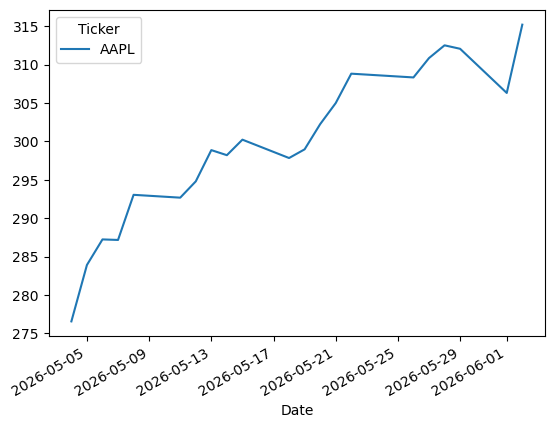

In [61]:
df.Close.plot() # Close指收盤價

<Axes: xlabel='Date'>

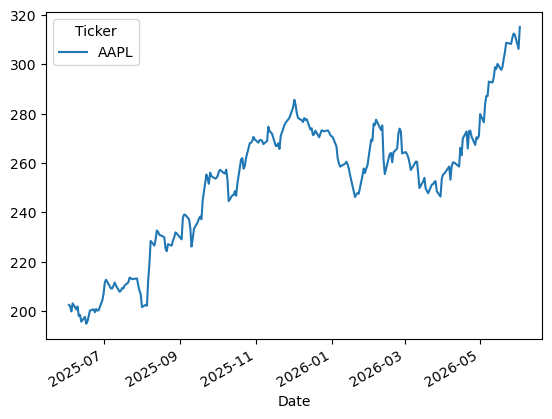

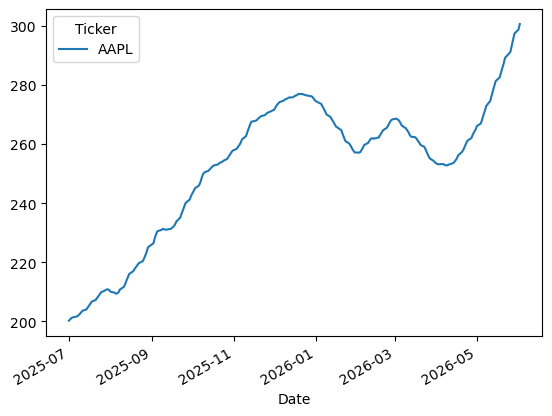

In [69]:
df.Close.plot()
df.Close.rolling(20).mean().plot()

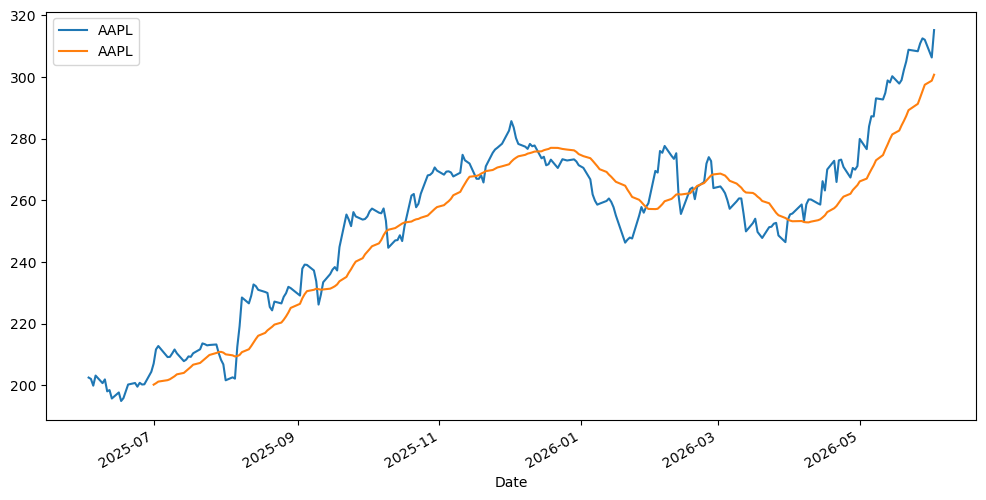

In [92]:
ax = df.Close.plot(figsize=(12,6), label="Close") # 圖大小為12 x 6，並把圖軸物件存入ax
df.Close.rolling(20).mean().plot(ax=ax,label="MA20")

plt.legend()
plt.show()

#### 20 日和 60 日的移動平均

<Axes: xlabel='Date'>

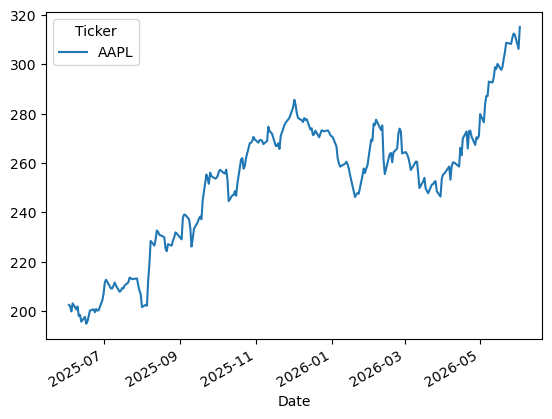

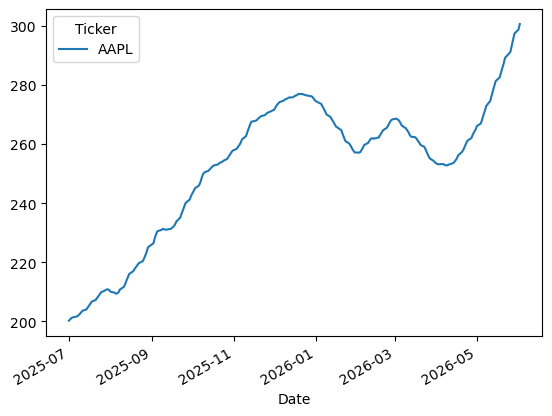

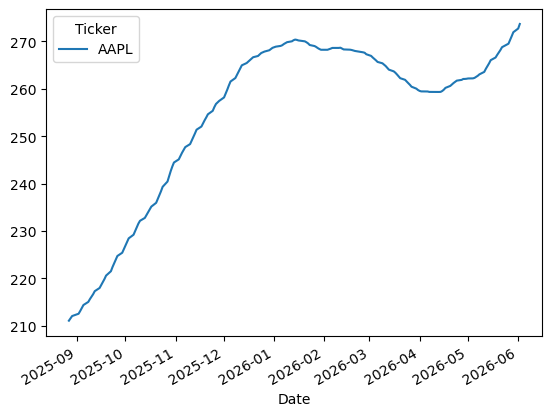

In [70]:
df.Close.plot(legend=True)
df.Close.rolling(20).mean().plot(label="$MA_{20}$",legend=True)
df.Close.rolling(60).mean().plot(label="$MA_{60}$",legend=True)

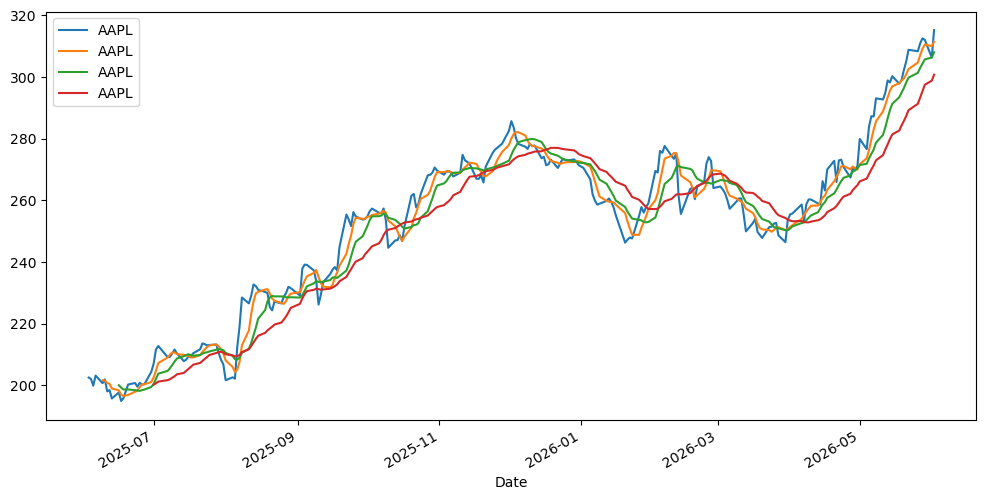

In [91]:
ax = df.Close.plot(figsize=(12,6), label='Close')

df.Close.rolling(5).mean().plot(ax=ax,label='MA5')
df.Close.rolling(10).mean().plot(ax=ax,label='MA10')
df.Close.rolling(20).mean().plot(ax=ax,label='MA20')

plt.legend()
plt.show()

#### 準備做預測

我們用個非常天真的模型...

![天真股票模型](images/naive.png)

網路上說這是線性的 (可能嗎)!


In [78]:
close = df.Close.values
len(close) # 不可寫Close

251

In [88]:
x = close[:-1] #slice切片語法，資料[開始:結束]
len(x)

250

In [83]:
y = close[1:]
len(y)

250

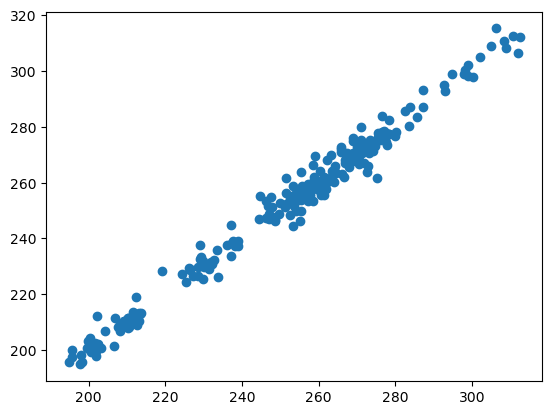

In [90]:
plt.scatter(x,y) # scatter用來繪製散佈圖的函數

哦, 真的有點像線性的, 我們之後用線性迴歸試試看。

## 9 手工打造一個 DataFrame*

有時我們用手工打造一個簡單的 DataFrame, 可以更理解整個結構。其實很容易, 一個 DataFrame 基本上就包含兩個主要部份:

* 資料本身: 通常一個二維陣列 (矩陣)
* 行、列的名稱

我們來個簡單的小例子。

In [94]:
mydata = np.random.randn(4,3)

In [95]:
mydata

array([[ 0.90038251, -0.9374541 ,  0.1239852 ],
       [ 1.7735947 , -0.79143219, -0.49104005],
       [ 0.48014392, -1.82951659,  0.57679483],
       [-0.19071982,  1.66438396, -1.06340021]])

把行列的名字放進去, 就成一個 DataFrame。我們列的部份先讓 Python 自己產生。

In [96]:
df2 = pd.DataFrame(mydata, columns=list("ABC"))

In [97]:
df2

,A,B,C
0,0.900383,-0.937454,0.123985
1,1.773595,-0.791432,-0.491040
2,0.480144,-1.829517,0.576795
3,-0.190720,1.664384,-1.063400


#### 兩個表格上下貼起來

我們再來生一個 DataFrame, 再「貼」起來。

In [98]:
df3 = pd.DataFrame(np.random.randn(3,3), columns=list("ABC"))

In [99]:
df3

,A,B,C
0,-1.519913,0.415173,0.254354
1,0.901218,-1.565667,0.659130
2,-1.024922,1.087777,0.394580


In [100]:
df4 = pd.concat([df2,df3],axis=0)

In [101]:
df4

,A,B,C
0,0.900383,-0.937454,0.123985
1,1.773595,-0.791432,-0.491040
2,0.480144,-1.829517,0.576795
3,-0.190720,1.664384,-1.063400
0,-1.519913,0.415173,0.254354
1,0.901218,-1.565667,0.659130
2,-1.024922,1.087777,0.394580


前面我們弄得亂七八糟的 index 重設一下。

In [103]:
df4.index = range(0,7)

In [104]:
df4

,A,B,C
0,0.900383,-0.937454,0.123985
1,1.773595,-0.791432,-0.491040
2,0.480144,-1.829517,0.576795
3,-0.190720,1.664384,-1.063400
4,-1.519913,0.415173,0.254354
5,0.901218,-1.565667,0.659130
6,-1.024922,1.087777,0.394580


#### 横向的貼

In [105]:
df5 = pd.concat([df2,df3],axis=1)

等等, 這大小好像不太對也可以嗎? 答案是可以的!

In [106]:
df5

,A,B,C,A,B,C
0,0.900383,-0.937454,0.123985,-1.519913,0.415173,0.254354
1,1.773595,-0.791432,-0.491040,0.901218,-1.565667,0.659130
2,0.480144,-1.829517,0.576795,-1.024922,1.087777,0.394580
3,-0.190720,1.664384,-1.063400,NaN,NaN,NaN


#### 大一點的例子

我們來做前面「假的」學測資料。首先要有「假的」同學名單, 如果有興趣產生很多名字, 可以用這個服務。

[中文姓名產生器](http://www.richyli.com/name/index.asp)

In [107]:
df_names = pd.read_csv("data/names.csv",names=["姓名"])

In [108]:
df_names

,姓名
0,羅雅慧
1,王紹尹
2,黃季坤
3,許正書
4,張鈞蓮
...,...
95,陳君生
96,曾桂甫
97,林欣怡
98,林佳霖


In [109]:
df_grades = pd.DataFrame(np.random.randint(6,16,(100,5)),
                        columns=['國文','英文','數學','社會','自然'])

In [114]:
df_names = pd.read_csv("data/grades.csv")
df_grades

,國文,英文,數學,社會,自然
0,14,15,12,6,13
1,6,14,9,12,8
2,6,10,15,14,9
3,13,7,12,11,7
4,12,15,9,10,7
...,...,...,...,...,...
95,14,15,8,8,7
96,7,13,14,6,7
97,11,14,12,11,9
98,6,13,11,15,15


In [112]:
df_score = pd.concat([df_names,df_grades],axis=1)
df_score

,姓名,國文,英文,數學,自然,社會,國文,英文,數學,社會,自然
0,劉俊安,9,10,15,10,13,14,15,12,6,13
1,胡玉華,10,10,10,8,9,6,14,9,12,8
2,黃淑婷,13,15,8,11,14,6,10,15,14,9
3,陳上紫,10,10,8,9,14,13,7,12,11,7
4,崔靜成,13,12,14,12,13,12,15,9,10,7
...,...,...,...,...,...,...,...,...,...,...,...
95,蔡佳燕,9,10,9,13,14,14,15,8,8,7
96,吳筱婷,8,10,14,10,15,7,13,14,6,7
97,陳家銘,14,9,11,8,12,11,14,12,11,9
98,李明威,15,9,8,9,15,6,13,11,15,15


In [118]:
df_x = pd.concat([df_names['姓名'], df_grades], axis=1)

In [119]:
df_x

,姓名,國文,英文,數學,社會,自然
0,劉俊安,14,15,12,6,13
1,胡玉華,6,14,9,12,8
2,黃淑婷,6,10,15,14,9
3,陳上紫,13,7,12,11,7
4,崔靜成,12,15,9,10,7
...,...,...,...,...,...,...
95,蔡佳燕,14,15,8,8,7
96,吳筱婷,7,13,14,6,7
97,陳家銘,11,14,12,11,9
98,李明威,6,13,11,15,15
